In [1]:
"""
water_mass_transport.py
author: Tahya Weiss-Gibbons (adapted by Grace Kirkpatrick)

Calculate the transport across a straight line section of a water mass
Gives volume, heat, freshwater and salt transport of the water mass
"""
import math
import datetime
import numpy as np
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset
import datetime
import matplotlib.pyplot as plt
import cftime
import time
import gsw

mkdir -p failed for path /home/grace/.config/matplotlib: [Errno 20] Not a directory: '/home/grace/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-o0ykyeiq because there was an issue with the default path (/home/grace/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [5]:
#gets the list of grid points for a straight section between two points
#uses the bresenham line algorithm
def plotLineLow(x0, x1, y0, y1):
    ii = []
    jj = []

    dx = x1 -x0
    dy = y1 - y0
    
    yi = 1
    if dy < 0:
        yi = -1
        dy = -dy
    D = (2*dy) - dx
    y = y0
    for x in range(x0, x1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            y = y+yi
            D = D+(2*(dy-dx))
            ii.append(x)
            jj.append(y)
        else:
            D = D+2*dy
    return ii, jj

def plotLineHigh(x0, x1, y0, y1):
    ii = []
    jj = []

    dx = x1 - x0
    dy = y1 - y0
    
    xi = 1
    if dx < 0:
        xi = -1
        dx = -dx
    D = (2*dx) - dy
    x = x0

    for y in range(y0, y1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            x = x+xi
            D = D + (2*(dx-dy))
            ii.append(x)
            jj.append(y)
        else:
            D = D + 2*dx
    return ii, jj

def section_calculation(x0, x1, y0, y1):
    if abs(y1-y0) < abs(x1-x0):
        if x0 > x1:
            ii, jj = plotLineLow(x1, x0, y1, y0)
        else:
            ii, jj = plotLineLow(x0, x1, y0, y1)
    else:
            if y0 > y1:
                ii, jj = plotLineHigh(x1, x0, y1, y0)
            else:
                ii, jj = plotLineHigh(x0, x1, y0, y1)
    return ii, jj
    
#then shifts ii jj indices (whole dataset indices) to subset indices 
def shift_subset_bounds(ii, jj):
    ii = [x - ii[0] for x in ii]
    jj = [x - jj[0] for x in jj]
    return ii, jj



In [70]:
def time_bounds(startyear, startmonth, startday, endyear, endmonth, endday):
    return [startyear, startmonth, startday, endyear, endmonth, endday]

def space_bounds(n1, n2, n3, n4):
    return [n1, n2, n3, n4]

def get_times(dates):
    start_time = datetime.date(dates[0], dates[1], dates[2])
    end_time = datetime.date(dates[3], dates[4], dates[5])

    #figure out all the dates we have model files
    delta = end_time - start_time
    times = []

    i = 0
    while i < delta.days+1:
        t = start_time + datetime.timedelta(days=i)
        if t.month == 2 and t.day == 29:
            t = datetime.date(t.year, 3, 1)
            i = i+6
        else:
            i = i+5
        times.append(t)

    return times

In [100]:
def preprocess_v(ds): 
    ds = ds[['vomecrty']]
    ds = ds.sel(x=slice(inds[0],inds[1] + 1))
    ds = ds.sel(y=slice(inds[2],inds[3] + 1))
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_u(ds): 
    ds = ds[['vozocrtx']]
    ds = ds.sel(x=slice(inds[0],inds[1]+ 1))
    ds = ds.sel(y=slice(inds[2],inds[3]+ 1))
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_t(ds): 
    ds = ds[['vosaline', 'votemper']]
    if inds[0]==inds[1]: ds = ds.sel(x_grid_T = inds[0])
    else: ds = ds.sel(x_grid_T=slice(inds[0], inds[1]))
    if inds[2]==inds[3]: ds = ds.sel(y_grid_T = inds[3])
    else: ds = ds.sel(y_grid_T=slice(inds[2], inds[3]))                         
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_mask(ds):
    ds = ds[['e1t', 'e2t', 'e3t', 'nav_lon_T_grid', 'nav_lat_T_grid', 'deptht', 'tmask']]
    if inds[0]==inds[1]: ds = ds.sel(x_grid_T = inds[0])
    else: ds = ds.sel(x_grid_T=slice(inds[0], inds[1]))
    if inds[2]==inds[3]: ds = ds.sel(y_grid_T = inds[3])
    else: ds = ds.sel(y_grid_T=slice(inds[2], inds[3]))                         
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all
    
def get_files(path, dpath, runid, times, inds):
    #need both the u and v components of velocity
    inds = inds
    mdl_files_v = []
    mdl_files_u = []
    mdl_files_t = []
    for t in times:
        mdl_files_v.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridV.nc")
        mdl_files_u.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridU.nc")
        mdl_files_t.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridT.nc")

    dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coords='minimal', preprocess=preprocess_v)
    du = xr.open_mfdataset(mdl_files_u, data_vars='minimal', coords='minimal', preprocess=preprocess_u)
    dt = xr.open_mfdataset(mdl_files_t, data_vars='minimal', coords='minimal', preprocess=preprocess_t)
    mask = xr.open_mfdataset(dpath+'ANHA4_mesh_mask.nc')

    return dv, du, dt, mask
    

In [109]:
def create_output_file(path, secname, runid, t_grid_file): 
    
    ncfile = Dataset(path + secname + runid, mode='w',format='NETCDF4') 
    ncfile.createDimension('time_counter', None)
    ncfile.createDimension('depth', len(t_grid_file['deptht'][:]))
    ncfile.createDimension('nav_lat', (t_grid_file['nav_lat_grid_T'].shape))
    ncfile.createDimension('nav_lon', (t_grid_file['nav_lon_grid_T'].shape))

    ncfile.createVariable('nav_lon', float, ('nav_lat', 'nav_lon'))
    ncfile.createVariable('nav_lat', float, ('nav_lat', 'nav_lon'))
    ncfile.createVariable('time_counter', int, ('time_counter',))
    ncfile.createVariable('depth', float, ('deptht',))
    ncfile.createVariable('mask', float, ('nav_lat', 'nav_lon'))
    
    ncfile.variables['time_counter'] = t_grid_file['time_counter'][:]
    ncfile.variables['depth'] = t_grid_file['deptht'][:]
    ncfile.variables['nav_lon'] = t_grid_file['nav_lon_T_grid'][:]
    ncfile.variables['nav_lat'] = t_grid_file['nav_lat_T_grid'][:]
    
    ncfile.createVariable('u_thick', float, ('depth', 'nav_lat', 'nav_lon'))
    ncfile.createVariable('v_thick', float, ('depth', 'nav_lat', 'nav_lon'))
    ncfile.createVariable('z_thick', float, ('depth', 'nav_lat', 'nav_lon'))
    
    ncfile.createVariable('u_trans', float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))
    ncfile.createVariable('v_trans', float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))
    ncfile.createVariable('ctemp', float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))
    ncfile.createVariable('asal', float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))
    ncfile.createVariable('rho', float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))

    ncfile.createVariable('u_t', float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))
    ncfile.createVariable('v_t', float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))
               
    return ncfile

def create_output_wmass(path, secname, runid, wmasses, time_series): 
    
    ncfile = Dataset(path + secname + runid + str(len(wmasses)) + '.nc', mode='w',format='NETCDF4') 
    ncfile.createDimension('time_counter', None)
    ncfile.createDimension('depth,' )
    ncfile.createDimension('alongpath,')
    ncfile.createVariable('time_counter', int, ('time_counter',))
    ncfile.variables['time_counter'] = time_series['time_counter'][:]

    for x in wmasses:
        ncfile.createVariable(x['name'] + 'vol' , float, ('time_counter',))
        ncfile.createVariable(x['name'] + 'sal' , float, ('time_counter',))
        ncfile.createVariable(x['name'] + 'heat' , float, ('time_counter',))
        ncfile.createVariable(x['name'] + 'fresh' , float, ('time_counter',))
    return ncfile
    
def get_rho_ct_asal(dt):
    pt = dt['votemper']
    ps = dt['vosaline']
    asal = gsw.SA_from_SP(ps, 10.1325, dt.nav_lon, dt.nav_lat)
    ct = gsw.CT_from_pt(asal, pt)
    rho = gsw.sigma0(asal, ct)
    
    return rho, ct, asal

def define_watermasses(names, density_bounds): # list of names, list of density characteristics, creates dictionary
    watermasses = []
    for x in range(len(names)):
        watermasses.append({'name':names[x], 'rho':density_bounds[x]})
    return watermasses 

is it faster to subset these datasets or does the additional overhead actually make it slower? or rather how much slower, bc i think using the gibbs formulas at every timestep rather than accessing density directly would be very slow indeed. 33 secs without subsetting; 99 for all three vars; *3 for all years for 5 minutes; 22 secs with subsetting; 66 for all three; 3.3 mins

In [112]:
m = xr.open_mfdataset('/mnt/storage6/grace/data/' + 'ANHA4_mesh_mask.nc')

OSError: no files to open

In [110]:
def transport_calculations(runid, secname, inds, dates):
    figs_path = '/mnt/storage6/grace/nwcorner/scripts/Figures/'
    path = "/mnt/storage6/myers/NEMO/ANHA4-" + runid + "/"
    other_path = '/mnt/storage6/grace/data/'

    #Define the transect and get the iijj list
    section = secname # maybe obsolete thi variable TO DO
    iit, jjt = section_calculation(inds[0], inds[1], inds[2], inds[3]) # temporary indices in full-output i/j coordinates
    ii, jj = shift_subset_bounds(iit, jjt) # indices shifted to subset i/j coordinates
    
    #get list of times in the dataset from the start date (YYYYMMDD) and end date (YYYYMMDD)
    times = get_times(dates)
    
    #load in dataset (u, v, t grids)
    dv, du, dt, mask = get_files(path, other_path, runid, times, inds)

    print('done loading')

    #read in the mask file
    e1t = mask['e1t'][0,:,:]
    e2t = mask['e2t'][0,:,:]
    e3t = mask['e3t'][:,:,:]
    tmask = mask['tmask'][0,:,:,:]

    #and finally the cell thickness
    cell_thickness_t = np.where(tmask, e3t, np.nan)

    #all quantities necessary to make output file now
    output = create_output_file(other_path, secname, runid, dt)
    
    output.variables['i_thick'] = e1t
    output.variables['j_thick'] = e2t
    output.variables['z_thick'] = e3t
    
    #now we need to get u and v on the t-grid by averaging u_i and u_(i+1), same for v
    u_t = du['vozocrtx'][:,:, :, :-1] /2 + du['vozocrtx'][:,:, :, 1:] /2
    v_t = dv['vomecrty'][:,:, :-1, :] /2 + dv['vomecrty'][:,:, 1:, :] /2

    output.variables['u_t'] = u_t[:,:,:,:]
    output.variables['v_t'] = v_t[:,:,:,:]

    print('done t gridding')
    
    #now that everything is on the t-grid we can use all of the t-grid coordinates and values. 
    #we calculate the area of the cell's vertical face along both the i and j axes

    i_tarea = e1t * e3t # area of vertical cell face along i-axis, for v 
    j_tarea = e2t * e3t # area of vertical cell face alone j-axis horizontal, for u

    v_trans = i_tarea * j_t # meridional transport
    u_trans = j_tarea * u_t # zonal transport

    output.variables['v_trans'] = v_trans[:,:,:,:] * .000001
    output.variables['u_trans'] = u_trans[:,:,:,:] * .000001

    #now we need conservative temp, absolute salinity, and potential density)
    rho, ctemp, asal = get_rho_ct_asal(dt)

    output.variables['rho'] = rho[:,:,:,:]
    output.variables['asal'] = asal[:,:,:,:]
    output.variables['ctemp'] = ctemp[:,:,:,:]

    mask = np.zeros(e3t.shape)

    for n in range(0,len(ii)):
        mask[:, ii[n], jj[n]] + 1
        
    mask = mask.astype(bool)
    output.variables['mask'] = mask[:,:]

    dt.close()

In [111]:
if __name__ == "__main__":
    dates = time_bounds(2004, 1, 5, 2005, 1, 5)
    inds = space_bounds(55+125, 85+125, 85+225, 85+225)
    transport_calculations('EPM151', 'pre_gb', inds, dates)

low line!


/tmp/ipykernel_1598911/3691329936.py:40: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coords='minimal', preprocess=preprocess_v)
/tmp/ipykernel_1598911/3691329936.py:40: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coord

OSError: no files to open

In [68]:
"""
def process_watermasses()


    v_sal = v_trans * vsal # meridional salinity transport
    u_sal = u_trans * asal # zonal salinity transport

    v_fresh = v_trans * (asal - ref_sal) # meridional freshwater transport
    u_fresh = u_trans * (asal - ref_sal) # zonal freshwater transport
    
    #and to see which velocity components are needed at each grid space

    #create netcdf file for all water masses being evaluated in the transect
    output_file = create_output_file(other_path, secname, runid, wmasses, dt)


                if S_max:
                v = v.where(sal < S, np.nan)
                sal = sal.where(sal < S, np.nan)
                temp = temp.where(sal < S, np.nan)
            else:
                v = v.where(sal > S, np.nan)
                sal = sal.where(sal > S, np.nan)
                temp = temp.where(sal > S, np.nan)
            if T_max:
                v = v.where(temp < T, np.nan)
                sal = sal.where(temp < T, np.nan)
                temp = temp.where(temp < T, np.nan)
            else:
                v = v.where(temp > T, np.nan)
                sal = sal.where(temp > T, np.nan)
                temp = temp.where(temp > T, np.nan)
    transects = [{'name':'Labrador Current', 'x01y01':[50+125,70+125,110+125,121+125]}, 
             {'name':'pre_GBanks', 'x01y01':[55+125,85+125,85+225,85+225]}, {'name':'Flemish Cap', 'x01y01':[57+125,95+125,70+225,70+25]}]
    watermasses = define_watermasses(['s_lc', 'u_lsw', 'l_lsw', 'gfz', 'dso'], [0,0,0,0,0])
"""

"\ndef process_watermasses()\n\n\n    v_sal = v_trans * vsal # meridional salinity transport\n    u_sal = u_trans * asal # zonal salinity transport\n\n    v_fresh = v_trans * (asal - ref_sal) # meridional freshwater transport\n    u_fresh = u_trans * (asal - ref_sal) # zonal freshwater transport\n\n    #and to see which velocity components are needed at each grid space\n\n    #create netcdf file for all water masses being evaluated in the transect\n    output_file = create_output_file(other_path, secname, runid, wmasses, dt)\n\n\n                if S_max:\n                v = v.where(sal < S, np.nan)\n                sal = sal.where(sal < S, np.nan)\n                temp = temp.where(sal < S, np.nan)\n            else:\n                v = v.where(sal > S, np.nan)\n                sal = sal.where(sal > S, np.nan)\n                temp = temp.where(sal > S, np.nan)\n            if T_max:\n                v = v.where(temp < T, np.nan)\n                sal = sal.where(temp < T, np.nan)\n 

In [60]:
ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridT.nc")
ds_u4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridU.nc")
u = ds_u4['vozocrtx'][0, :, 180:190, 200:210]
mask = np.zeros((10,10))
py = [0,1,2,3,4,5,6,7,8,9]
px = [0,1,2,3,4,5,6,7,8,9]

In [51]:
for z in range(10):
    mask[px[z], py[z]] = 1

In [52]:
mask = mask.astype(bool)

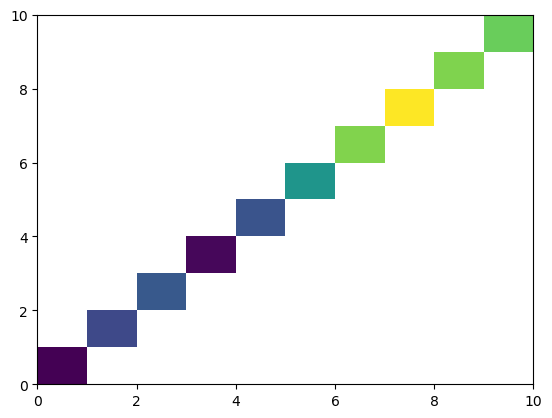

In [57]:
plt.pcolormesh(np.where(mask, u, np.nan))